# Encoder ceiling on real RAVDESS test split

Establishes the upper bound for any downstream classifier on Wav2Lip-generated
frames: the F1 of the frozen audio (HuBERT) and video (TimeSformer) encoders
themselves on the real, ungenerated test data.

The internal-encoder F1 in `06_finetune_wav2lip.ipynb` cannot exceed this ceiling —
generated frames are not classified more accurately than the encoder classifies
real ones. Reporting this ceiling is what lets the thesis answer the reviewer
question: *is your model approaching the ceiling, or is the loss the bottleneck?*

In [1]:
!pip install -q transformers librosa scipy scikit-learn
!git clone https://github.com/Rudrabha/Wav2Lip.git 2>/dev/null || true

In [ ]:
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import sys
sys.path.insert(0, "/content")
sys.path.insert(0, "/content/Wav2Lip")

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchaudio
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, f1_score, precision_recall_fscore_support,
)
from tqdm import tqdm

from emotion_utils import (
    DifferentiableVideoPreprocess,
    load_frozen_audio_encoder,
    load_frozen_video_encoder,
)

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
METADATA = "/content/processed_data/metadata.json"
BEST_AUDIO_PATH = "/content/trained_encoders_4emotions/4emo-hubert-er-lr3e5-nf"
BEST_VIDEO_PATH = "/content/trained_encoders_4emotions/4emo-tsf-lr3e5-16f-nf"
OUT_DIR = Path("/content/encoder_ceiling_4emo")
OUT_DIR.mkdir(parents=True, exist_ok=True)

EMOTIONS = ["happy", "sad", "angry", "disgust"]
EXCLUDE = {0, 1, 5, 7}  # neutral, calm
REMAP = {2: 0, 3: 1, 4: 2, 6: 3}
WAV2LIP_TO_ENCODER = [2, 3, 4, 6]
NUM_EMO = len(EMOTIONS)
MAX_AUDIO_S = 3.0  # matches 04/02 audio crop
SPLIT = "test"

print(f"Device: {DEVICE}")
print(f"Audio encoder: {BEST_AUDIO_PATH}")
print(f"Video encoder: {BEST_VIDEO_PATH}")

In [3]:
audio_enc, audio_proc = load_frozen_audio_encoder(BEST_AUDIO_PATH, DEVICE)
video_enc = load_frozen_video_encoder(BEST_VIDEO_PATH, DEVICE)
video_preprocess = DifferentiableVideoPreprocess(224).to(DEVICE)

VIDEO_ENC_FRAMES = int(getattr(video_enc.config, "num_frames", 8))
AUDIO_HEAD_LABELS = int(getattr(audio_enc.config, "num_labels", NUM_EMO))
VIDEO_HEAD_LABELS = int(getattr(video_enc.config, "num_labels", NUM_EMO))

print(f"Video encoder expects {VIDEO_ENC_FRAMES} frames per clip.")
print(f"Audio head labels: {AUDIO_HEAD_LABELS} | Video head labels: {VIDEO_HEAD_LABELS}")

Video encoder expects 8 frames per clip.
Audio head labels: 6 | Video head labels: 6


In [4]:
def remap_logits(logits, head_labels):
    """If head produces all 8 RAVDESS classes, slice to our 6 (drop neutral, calm)."""
    if head_labels == NUM_EMO:
        return logits
    return logits[:, WAV2LIP_TO_ENCODER]


def adapt_frames_to_n(frames_thwc, target_t):
    """frames_thwc: (T, H, W, 3) numpy in [0, 1]. Returns (target_t, 3, H, W) tensor."""
    T = frames_thwc.shape[0]
    if T == target_t:
        idx = np.arange(target_t)
    else:
        idx = np.linspace(0, T - 1, target_t).round().astype(int)
    sampled = frames_thwc[idx]
    return torch.from_numpy(sampled).permute(0, 3, 1, 2).float()


@torch.no_grad()
def predict_video(frames_thwc):
    frames = adapt_frames_to_n(frames_thwc, VIDEO_ENC_FRAMES).to(DEVICE)
    pv = video_preprocess(frames.unsqueeze(0))
    out = video_enc(pixel_values=pv)
    logits = remap_logits(out.logits, VIDEO_HEAD_LABELS)
    return int(logits.argmax(dim=-1).item())


@torch.no_grad()
def predict_audio(wav_1d):
    sr = getattr(audio_proc, "sampling_rate", 16000)
    enc = audio_proc([wav_1d.numpy()], sampling_rate=sr, return_tensors="pt",
                     padding="max_length", truncation=True,
                     max_length=int(MAX_AUDIO_S * sr))
    kwargs = {"input_values": enc["input_values"].to(DEVICE)}
    if "attention_mask" in enc:
        kwargs["attention_mask"] = enc["attention_mask"].to(DEVICE)
    out = audio_enc(**kwargs)
    logits = remap_logits(out.logits, AUDIO_HEAD_LABELS)
    return int(logits.argmax(dim=-1).item())

In [5]:
with open(METADATA) as f:
    meta = json.load(f)
samples = [s for s in meta if s["split"] == SPLIT and s["emotion_idx"] not in EXCLUDE]
print(f"Real {SPLIT} samples: {len(samples)}")

from collections import Counter
print("Per-emotion counts:",
      dict(Counter(EMOTIONS[REMAP[s['emotion_idx']]] for s in samples)))

audio_labels, audio_preds = [], []
video_labels, video_preds = [], []

for s in tqdm(samples, desc=f"real {SPLIT}"):
    true = REMAP[s["emotion_idx"]]

    wav, _ = torchaudio.load(s["audio_path"])
    audio_labels.append(true)
    audio_preds.append(predict_audio(wav.squeeze(0)))

    frames = np.load(s["frames_path"]).astype(np.float32) / 255.0  # (T, H, W, 3)
    video_labels.append(true)
    video_preds.append(predict_video(frames))

audio_labels = np.array(audio_labels)
audio_preds = np.array(audio_preds)
video_labels = np.array(video_labels)
video_preds = np.array(video_preds)
print("Done.")

Real test samples: 144
Per-emotion counts: {'happy': 24, 'sad': 24, 'angry': 24, 'fearful': 24, 'disgust': 24, 'surprised': 24}


real test: 100%|██████████| 144/144 [00:12<00:00, 11.52it/s]

Done.



=== audio encoder on REAL test frames/audio ===
  macro F1: 0.6980
  emotion        P        R       F1  support
    happy 0.527778 0.791667 0.633333       24
      sad 0.629630 0.708333 0.666667       24
    angry 0.777778 0.583333 0.666667       24
  fearful 0.720000 0.750000 0.734694       24
  disgust 1.000000 0.583333 0.736842       24
surprised 0.750000 0.750000 0.750000       24

  Confusion matrix (rows=true, cols=predicted):
           happy  sad  angry  fearful  disgust  surprised
happy         19    3      0        2        0          0
sad            6   17      0        1        0          0
angry          3    0     14        3        0          4
fearful        2    4      0       18        0          0
disgust        1    3      4        0       14          2
surprised      5    0      0        1        0         18


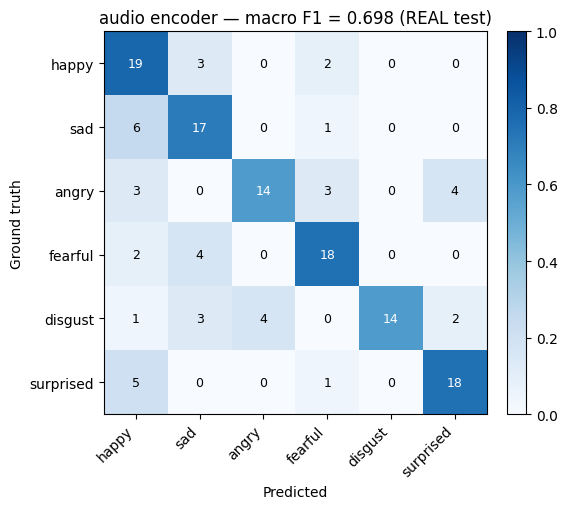

  -> saved /content/encoder_ceiling/encoder_ceiling_audio.png

=== video encoder on REAL test frames/audio ===
  macro F1: 0.6725
  emotion        P        R       F1  support
    happy 0.606061 0.833333 0.701754       24
      sad 0.705882 0.500000 0.585366       24
    angry 0.937500 0.625000 0.750000       24
  fearful 0.857143 0.500000 0.631579       24
  disgust 0.952381 0.833333 0.888889       24
surprised 0.372093 0.666667 0.477612       24

  Confusion matrix (rows=true, cols=predicted):
           happy  sad  angry  fearful  disgust  surprised
happy         20    0      0        0        0          4
sad            5   12      0        2        0          5
angry          0    0     15        0        0          9
fearful        0    2      0       12        1          9
disgust        1    3      0        0       20          0
surprised      7    0      1        0        0         16


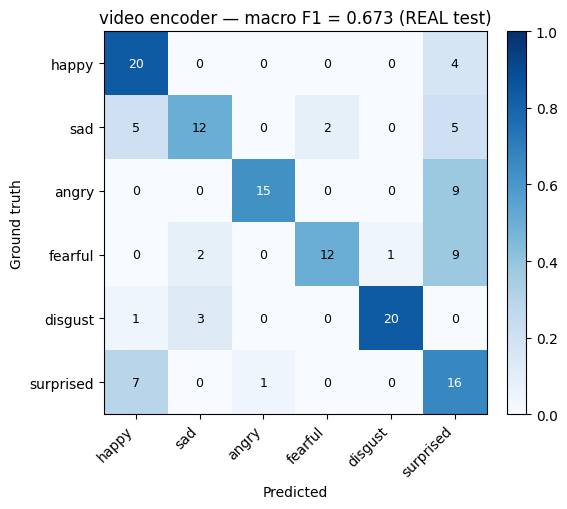

  -> saved /content/encoder_ceiling/encoder_ceiling_video.png


In [6]:
def report_and_plot(name, labels, preds):
    macro_f1 = float(f1_score(labels, preds,
                              labels=list(range(NUM_EMO)), average="macro", zero_division=0))
    prec, rec, per_f1, sup = precision_recall_fscore_support(
        labels, preds, labels=list(range(NUM_EMO)), zero_division=0)
    cm = confusion_matrix(labels, preds, labels=list(range(NUM_EMO)))

    print(f"\n=== {name} encoder on REAL test frames/audio ===")
    print(f"  macro F1: {macro_f1:.4f}")
    rows = [{"emotion": e, "P": prec[i], "R": rec[i], "F1": per_f1[i],
             "support": int(sup[i])} for i, e in enumerate(EMOTIONS)]
    per_df = pd.DataFrame(rows)
    print(per_df.to_string(index=False))

    print(f"\n  Confusion matrix (rows=true, cols=predicted):")
    print(pd.DataFrame(cm, index=EMOTIONS, columns=EMOTIONS).to_string())

    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(NUM_EMO))
    ax.set_yticks(range(NUM_EMO))
    ax.set_xticklabels(EMOTIONS, rotation=45, ha="right")
    ax.set_yticklabels(EMOTIONS)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Ground truth")
    ax.set_title(f"{name} encoder — macro F1 = {macro_f1:.3f} (REAL test)")
    for i in range(NUM_EMO):
        for j in range(NUM_EMO):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                    fontsize=9, color="white" if cm_norm[i, j] > 0.5 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig_path = OUT_DIR / f"encoder_ceiling_{name}.png"
    fig.savefig(fig_path, dpi=120)
    plt.show()
    print(f"  -> saved {fig_path}")
    return macro_f1, per_f1


audio_macro, audio_per = report_and_plot("audio", audio_labels, audio_preds)
video_macro, video_per = report_and_plot("video", video_labels, video_preds)

In [7]:
summary = pd.DataFrame([
    {
        "encoder": "audio (HuBERT)",
        "macro_F1": audio_macro,
        **{f"F1_{e}": audio_per[i] for i, e in enumerate(EMOTIONS)},
    },
    {
        "encoder": "video (TimeSformer)",
        "macro_F1": video_macro,
        **{f"F1_{e}": video_per[i] for i, e in enumerate(EMOTIONS)},
    },
])
csv_path = OUT_DIR / "encoder_ceiling.csv"
summary.to_csv(csv_path, index=False)
print(f"Summary -> {csv_path}")
print(summary.to_string(index=False))

Summary -> /content/encoder_ceiling/encoder_ceiling.csv
            encoder  macro_F1  F1_happy   F1_sad  F1_angry  F1_fearful  F1_disgust  F1_surprised
     audio (HuBERT)  0.698034  0.633333 0.666667  0.666667    0.734694    0.736842      0.750000
video (TimeSformer)  0.672533  0.701754 0.585366  0.750000    0.631579    0.888889      0.477612


## Interpretation for thesis

- The **video encoder macro F1** above is the absolute ceiling for the internal
  metric reported in `06_finetune_wav2lip.ipynb`. If 06's best F1 is close to
  this number, the loss is doing its job — the bottleneck is encoder accuracy,
  not optimization. If 04 is far below the ceiling, there is still room to push.
- The **audio encoder F1** sets the quality of the KL reference distribution
  used in 06's CE+KL loss. Per-emotion F1 here predicts which emotions the KL
  distillation can supervise reliably (high F1) and which it cannot (low F1
  → KL noise, e.g. *fearful* tends to be the weakest in RAVDESS audio).
- The **per-emotion gap** between this ceiling and 06's per-emotion F1 is what
  belongs in the Limitations subsection: errors trace back partly to encoder
  capacity, not just to the generator.
- The external evaluation in `05_external_evaluation.ipynb` (FER ViT trained on
  in-the-wild data) is independent of this ceiling — it measures whether the
  generator preserves emotion in the eyes of a *different* observer.